# 01 · Exploratory Data Analysis (EDA)

**Goal:** load the raw smartphone dataset and understand its structure, quality, and key
patterns before any cleaning or modeling is done.

This notebook only *reads* `Mobile Dataset.csv` — it does not modify or save anything.
Cleaning and feature engineering happen in `02_preprocessing.ipynb`.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

## 1.1 Load the dataset

> Update `DATA_PATH` below if `Mobile Dataset.csv` lives somewhere else on your machine.

In [2]:
DATA_PATH = r"Mobile Dataset.csv"
df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (32000, 10)


,platform,brand,product_name,category,price,rating,ram,storage,battery,url
0,Croma,Vivo,Vivo vivo-68-fe,Smartphone,26216,4.6,16GB,512GB,5000mAh,https://croma.com/vivo-vivo-model-68
1,Reliance Digital,Apple,Apple iPhone 12,Smartphone,42356,4.0,4GB,128GB,4000mAh,https://reliancedigital.com/apple-iphone-12
2,Myntra,Vivo,Vivo Vivo Y21,Smartphone,42332,3.8,12GB,512GB,4000mAh,https://myntra.com/vivo-vivo-y21
3,Croma,Xiaomi,Xiaomi Redmi Note 11,Smartphone,72791,4.6,4GB,512GB,5500mAh,https://croma.com/xiaomi-redmi-note-11
4,Myntra,Vivo,Vivo Vivo V29,Smartphone,74376,4.1,16GB,512GB,5500mAh,https://myntra.com/vivo-vivo-v29


## 1.2 Structure, data types, missing values, duplicates

In [3]:
print("Column data types:")
print(df.dtypes)

print("\nMissing values per column:")
print(df.isna().sum())

print("\nNumber of duplicate rows:", df.duplicated().sum())

Column data types:
platform         object
brand            object
product_name     object
category         object
price             int64
rating          float64
ram              object
storage          object
battery          object
url              object
dtype: object

Missing values per column:
platform        0
brand           0
product_name    0
category        0
price           0
rating          0
ram             0
storage         0
battery         0
url             0
dtype: int64

Number of duplicate rows: 0


## 1.3 Parse numeric values out of text columns (for plotting only)

`ram`, `storage`, and `battery` are stored as strings like `"8GB"` / `"1TB"` / `"5000mAh"`.
These parsed copies (`ram_gb`, `storage_gb`, `battery_mah`) are only for EDA plots below —
the real, more careful cleaning happens in `02_preprocessing.ipynb`.

In [4]:
df["ram_gb"]      = df["ram"].str.replace("GB", "", regex=False).astype(float)
df["storage_gb"]  = (
    df["storage"].str.replace("TB", "000", regex=False)
    .str.replace("GB", "", regex=False).astype(float)
)
df["battery_mah"] = df["battery"].str.replace("mAh", "", regex=False).astype(float)

## 1.4 Summary statistics

In [5]:
print("Summary statistics:")
df[["price", "rating", "ram_gb", "storage_gb", "battery_mah"]].describe().transpose()

Summary statistics:


,count,mean,std,min,25%,50%,75%,max
price,32000.0,41786.395219,19291.785462,8156.0,25133.75,39922.0,57761.0,81894.0
rating,32000.0,4.215628,0.404792,3.5,3.90,4.2,4.5,5.0
ram_gb,32000.0,9.162375,4.296360,4.0,6.00,8.0,12.0,16.0
storage_gb,32000.0,390.801750,340.654348,64.0,128.00,256.0,512.0,1000.0
battery_mah,32000.0,5005.625000,706.708633,4000.0,4500.00,5000.0,5500.0,6000.0


## 1.5 Visual EDA: distributions, brand comparisons, correlations

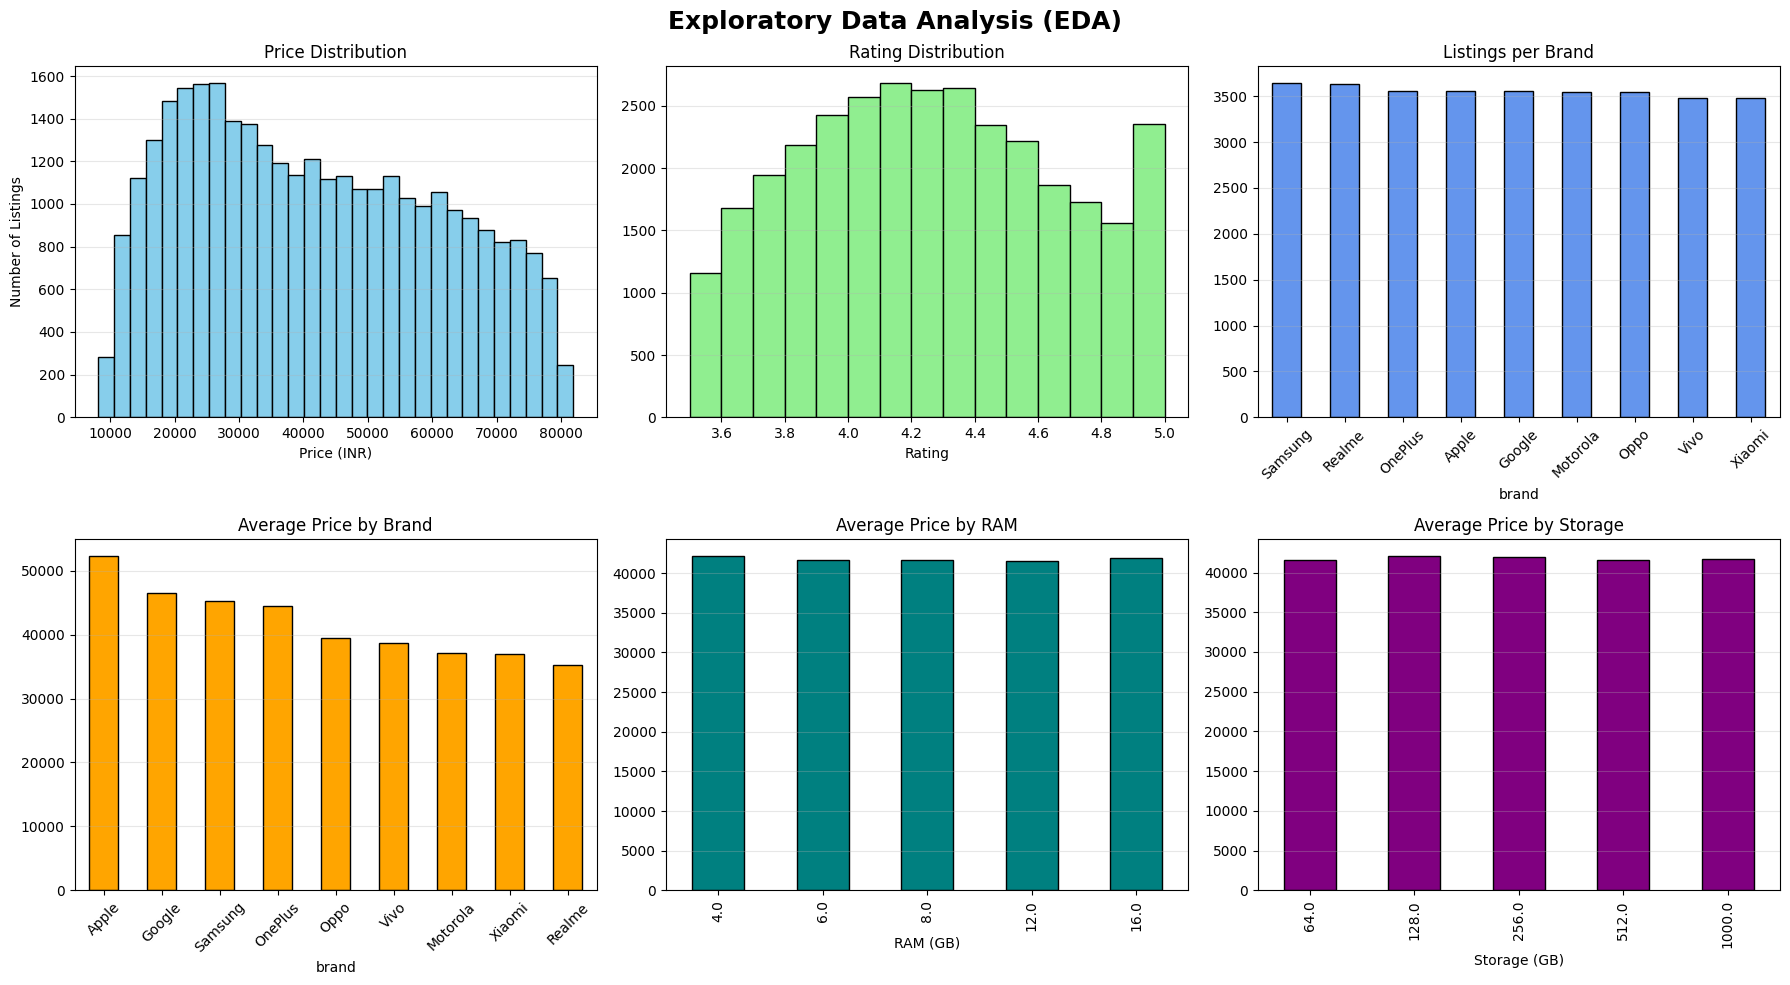

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Exploratory Data Analysis (EDA)", fontsize=18, fontweight="bold")

# Price distribution
axes[0, 0].hist(df["price"], bins=30, edgecolor="black", color="skyblue")
axes[0, 0].set_title("Price Distribution")
axes[0, 0].set_xlabel("Price (INR)")
axes[0, 0].set_ylabel("Number of Listings")
axes[0, 0].grid(axis="y", alpha=0.3)

# Rating distribution
axes[0, 1].hist(df["rating"], bins=15, edgecolor="black", color="lightgreen")
axes[0, 1].set_title("Rating Distribution")
axes[0, 1].set_xlabel("Rating")
axes[0, 1].grid(axis="y", alpha=0.3)

# Listings per brand
brand_counts = df["brand"].value_counts()
brand_counts.plot(kind="bar", ax=axes[0, 2], edgecolor="black", color="cornflowerblue")
axes[0, 2].set_title("Listings per Brand")
axes[0, 2].tick_params(axis="x", rotation=45)
axes[0, 2].grid(axis="y", alpha=0.3)

# Average price by brand
avg_price_by_brand = df.groupby("brand")["price"].mean().sort_values(ascending=False)
avg_price_by_brand.plot(kind="bar", ax=axes[1, 0], edgecolor="black", color="orange")
axes[1, 0].set_title("Average Price by Brand")
axes[1, 0].tick_params(axis="x", rotation=45)
axes[1, 0].grid(axis="y", alpha=0.3)

# Average price by RAM
df.groupby("ram_gb")["price"].mean().plot(kind="bar", ax=axes[1, 1], edgecolor="black", color="teal")
axes[1, 1].set_title("Average Price by RAM")
axes[1, 1].set_xlabel("RAM (GB)")
axes[1, 1].grid(axis="y", alpha=0.3)

# Average price by storage
df.groupby("storage_gb")["price"].mean().plot(kind="bar", ax=axes[1, 2], edgecolor="black", color="purple")
axes[1, 2].set_title("Average Price by Storage")
axes[1, 2].set_xlabel("Storage (GB)")
axes[1, 2].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

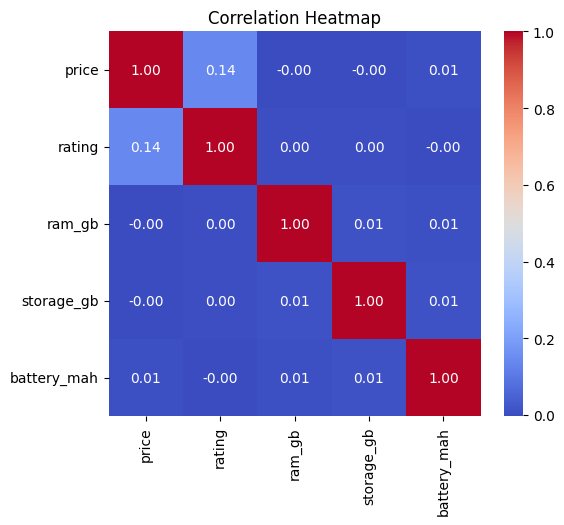

In [7]:
# Correlation heatmap
numeric_cols = ["price", "rating", "ram_gb", "storage_gb", "battery_mah"]
plt.figure(figsize=(6, 5))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

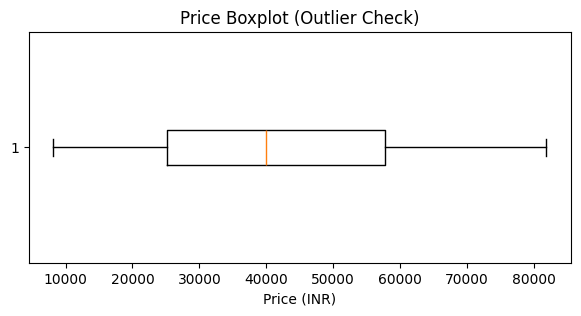

In [8]:
# Outlier check on price
plt.figure(figsize=(7, 3))
plt.boxplot(df["price"], vert=False)
plt.title("Price Boxplot (Outlier Check)")
plt.xlabel("Price (INR)")
plt.show()

## 1.6 Data quality check: same specs, very different price

If two listings share identical specs but have very different prices, that's a red flag for
modeling: the model sees the same input but is asked to predict two different targets.

In [9]:
spec_cols = ["brand", "ram", "storage", "battery", "rating", "platform"]
price_check = df.groupby(spec_cols)["price"].agg(["min", "max", "count"])
price_check["price_gap"] = price_check["max"] - price_check["min"]
repeated_specs = price_check[price_check["count"] > 1]

print("Spec combinations that appear more than once:", len(repeated_specs))
print("Rows affected:", repeated_specs["count"].sum(), "out of", len(df))
if len(repeated_specs) > 0:
    print("Average price gap for repeated specs: Rs", round(repeated_specs["price_gap"].mean()))

Spec combinations that appear more than once: 4770
Rows affected: 10259 out of 32000
Average price gap for repeated specs: Rs 21330


---
**Next:** `02_preprocessing.ipynb` — cleaning, encoding, feature engineering, and the
train/test split.